In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


DATA_DIR = Path(r"C:\Users\MYSTHIC\Documents\Andat\Program\dataset")

excel_paths = sorted(DATA_DIR.glob('*.xls'))

print("Cek struktur kolom dataset ISPU")

for p in excel_paths:
    try:
        dfs = pd.read_html(p)
        
        df = dfs[0]
        kolom = df.columns.tolist()
        
        print(f"\nFile: {p.name}")
        print(f"Jumlah kolom: {len(kolom)}")
        print(f"Daftar kolom: {kolom}")
    except ValueError as ve:
        print(f"Gagal membaca {p.name}: {ve}")
    except Exception as e:
        print(f"Gagal membaca {p.name}: {e}")

print("\nSelesai cek struktur kolom.")

Cek struktur kolom dataset ISPU

File: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 - tabel.xls
Jumlah kolom: 12
Daftar kolom: ['periode_data', 'tanggal', 'stasiun', 'pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max', 'parameter_pencemar_kritis', 'kategori']

File: Data_Indeks Standar Pencemaran Udara di SPKU DKI Jakarta Tahun 2018 - tabel.xls
Jumlah kolom: 11
Daftar kolom: ['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']

File: Data_Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017 - tabel.xls
Jumlah kolom: 11
Daftar kolom: ['periode_data', 'tanggal', 'wilayah', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'kategori']

File: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2010 - tabel.xls
Jumlah kolom: 11
Daftar kolom: ['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']

File: Indeks_Standa

In [77]:
excel_paths = sorted(DATA_DIR.glob('*.xls'))

# 1. Kamus (Dictionary) untuk pemetaan nama kolom agar seragam
# Format: {'nama_kolom_lama': 'nama_kolom_standar'}
kolom_mapping = {
    'wilayah': 'stasiun',
    'lokasi_spku': 'stasiun',
    'pm_sepuluh': 'pm10',
    'pm_10': 'pm10',
    'pm_duakomalima': 'pm25',
    'sulfur_dioksida': 'so2',
    'karbon_monoksida': 'co',
    'ozon': 'o3',
    'nitrogen_dioksida': 'no2',
    'parameter_pencemar_kritis': 'critical',
    'categori': 'kategori'
}

semua_data = []

print("Mulai gabung data...")

for p in excel_paths:
    try:
        df = pd.read_html(p)[0]
        
        # Bersihkan nama kolom bawaan dulu (jadikan huruf kecil & hapus spasi tersembunyi)
        df.columns = df.columns.str.lower().str.strip()
        
        # 2. Ganti nama kolom menggunakan kamus yang sudah dibuat
        df.rename(columns=kolom_mapping, inplace=True)
        
        semua_data.append(df)
        print(f"Proses file: {p.name}, baris: {len(df)}")
        
    except Exception as e:
        print(f"Gagal proses {p.name}: {e}")

# 3. Gabungkan semua dataframe di dalam list menjadi satu DataFrame utuh
df_master = pd.concat(semua_data, ignore_index=True)

print("\nGabung data selesai.")
print(f"Total baris: {df_master.shape[0]}")
print(f"Total kolom: {df_master.shape[1]}")
print(f"Kolom data: {df_master.columns.tolist()}")

Mulai gabung data...
Proses file: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta 2023 - tabel.xls, baris: 1825
Proses file: Data_Indeks Standar Pencemaran Udara di SPKU DKI Jakarta Tahun 2018 - tabel.xls, baris: 1825
Proses file: Data_Indeks Standar Pencemaran Udara DKI Jakarta Tahun 2017 - tabel.xls, baris: 1825
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2010 - tabel.xls, baris: 1825
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2011 - tabel.xls, baris: 365
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2012 - tabel.xls, baris: 366
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2013 - tabel.xls, baris: 365
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2014 - tabel.xls, baris: 1825
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2015 - tabel.xls, baris: 365
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Tahun 2016 - tabel.xls, baris: 1830
Proses file: Indeks_Standar Pencemaran Udara (ISPU) Ta

In [78]:
print("Sanity check data")

print("\n1) Info tipe data dan missing values:")
# info() akan otomatis mencetak ke terminal
df_master.info()

print("\n2) Distribusi kategori:")
print(df_master['kategori'].value_counts(dropna=False))

print("\n3) Distribusi stasiun:")
print(df_master['stasiun'].value_counts(dropna=False))

print("\n4) Contoh nilai unik kolom polutan:")
# Kalau isinya cuma angka, tipe datanya pasti int64 atau float64.
# Kalau tipe datanya 'object', berarti ada teks nyelip. Kita intip 15 nilai unik pertamanya:
kolom_polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
for col in kolom_polutan:
    if col in df_master.columns:
        print(f"- {col}: {df_master[col].unique()[:15]}")

Sanity check data

1) Info tipe data dan missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15682 entries, 0 to 15681
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   periode_data  15682 non-null  int64 
 1   tanggal       15682 non-null  object
 2   stasiun       15682 non-null  object
 3   pm10          15639 non-null  object
 4   pm25          3953 non-null   object
 5   so2           15626 non-null  object
 6   co            15631 non-null  object
 7   o3            15591 non-null  object
 8   no2           15609 non-null  object
 9   max           15654 non-null  object
 10  critical      14241 non-null  object
 11  kategori      15678 non-null  object
dtypes: int64(1), object(11)
memory usage: 1.4+ MB

2) Distribusi kategori:
kategori
SEDANG                9037
BAIK                  2299
TIDAK SEHAT           2269
TIDAK ADA DATA        1444
SANGAT TIDAK SEHAT     228
TIDAKSEHAT             198

In [79]:
print("Data cleaning")

# 1. Bersihkan Kolom Polutan (Ubah '-' jadi NaN, lalu ubah tipe data ke Numerik/Float)
kolom_numerik = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max']
for col in kolom_numerik:
    if col in df_master.columns:
        # pd.to_numeric dengan errors='coerce' akan memaksa text aneh ('-', '---') menjadi NaN
        df_master[col] = pd.to_numeric(df_master[col], errors='coerce')

# 2. Bersihkan Kolom 'kategori' (Perbaiki typo dan buang data yang bergeser)
if 'kategori' in df_master.columns:
    # Jadikan huruf besar semua dan hilangkan spasi di awal/akhir kata
    df_master['kategori'] = df_master['kategori'].astype(str).str.upper().str.strip()
    
    # Perbaiki Typo
    df_master['kategori'] = df_master['kategori'].replace({
        'TIDAKSEHAT': 'TIDAK SEHAT',
        'TIDAKADADATA': 'TIDAK ADA DATA'
    })
    
    # Kita hanya ambil baris data yang kategorinya valid secara aturan ISPU
    kategori_valid = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
    df_master = df_master[df_master['kategori'].isin(kategori_valid)]

# 3. Bersihkan Kolom 'stasiun' (Seragamkan nama)
def standarisasi_stasiun(nama):
    nama = str(nama).upper()
    if 'DKI1' in nama: return 'DKI1 (BUNDERAN HI)'
    elif 'DKI2' in nama: return 'DKI2 (KELAPA GADING)'
    elif 'DKI3' in nama: return 'DKI3 (JAGAKARSA)'
    elif 'DKI4' in nama: return 'DKI4 (LUBANG BUAYA)'
    elif 'DKI5' in nama: return 'DKI5 (KEBON JERUK)'
    else: return np.nan # Kalau ada nama aneh (kayak 'SEDANG'), jadikan NaN

if 'stasiun' in df_master.columns:
    df_master['stasiun'] = df_master['stasiun'].apply(standarisasi_stasiun)
    # Buang baris yang stasiunnya NaN (imbas dari data bergeser tadi)
    df_master.dropna(subset=['stasiun'], inplace=True)

# Cek hasil akhirnya
print("\nInfo data setelah cleaning:")
df_master.info()

print("\nDistribusi kategori:")
print(df_master['kategori'].value_counts())

print("\nDistribusi stasiun:")
print(df_master['stasiun'].value_counts())

Data cleaning

Info data setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 14030 entries, 0 to 15681
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   periode_data  14030 non-null  int64  
 1   tanggal       14030 non-null  object 
 2   stasiun       14030 non-null  object 
 3   pm10          13478 non-null  float64
 4   pm25          3618 non-null   float64
 5   so2           13748 non-null  float64
 6   co            13831 non-null  float64
 7   o3            13663 non-null  float64
 8   no2           13701 non-null  float64
 9   max           14030 non-null  float64
 10  critical      14030 non-null  object 
 11  kategori      14030 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 1.4+ MB

Distribusi kategori:
kategori
SEDANG                9035
TIDAK SEHAT           2467
BAIK                  2299
SANGAT TIDAK SEHAT     228
BERBAHAYA                1
Name: count, dtype: int

In [80]:
print("Handling missing values dan outlier")

# 1. Hapus kolom 'pm25' (terlalu banyak NaN) dan 'periode_data' (tidak relevan untuk model)
kolom_dihapus = ['pm25', 'periode_data']
df_master.drop(columns=[col for col in kolom_dihapus if col in df_master.columns], inplace=True)

# 2. Hapus 1 baris kelas 'BERBAHAYA'
df_master = df_master[df_master['kategori'] != 'BERBAHAYA']

# 3. Imputasi (Isi data kosong) pada polutan lain dengan nilai MEDIAN berdasarkan 'stasiun'
kolom_imputasi = ['pm10', 'so2', 'co', 'o3', 'no2', 'max']
for col in kolom_imputasi:
    # Mengisi NaN dengan median dari stasiun yang sama
    df_master[col] = df_master.groupby('stasiun')[col].transform(lambda x: x.fillna(x.median()))

# 4. Drop sisa baris yang mungkin masih NaN di kolom target (kategori) atau stasiun
df_master.dropna(subset=['kategori', 'stasiun'], inplace=True)

print("Missing values setelah imputasi:")
print(df_master.isna().sum())

print(f"Bentuk data akhir: {df_master.shape}")

Handling missing values dan outlier
Missing values setelah imputasi:
tanggal     0
stasiun     0
pm10        0
so2         0
co          0
o3          0
no2         0
max         0
critical    0
kategori    0
dtype: int64
Bentuk data akhir: (14029, 10)


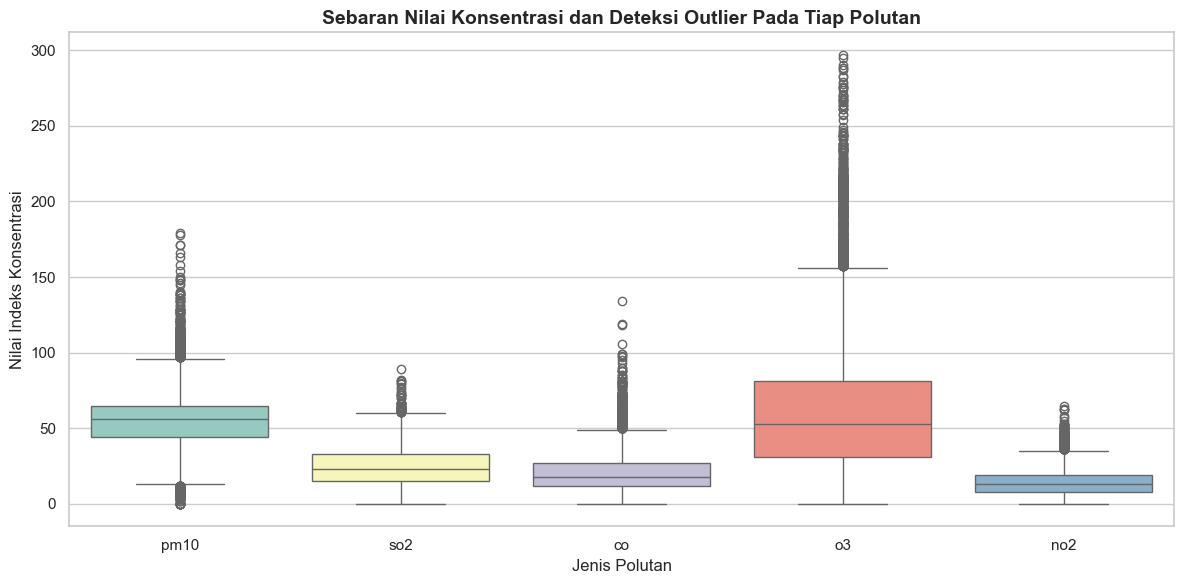

In [81]:
plt.figure(figsize=(12, 6))

df_melted = df_master.melt(id_vars=['kategori'], value_vars=['pm10', 'so2', 'co', 'o3', 'no2'], 
                           var_name='Jenis Polutan', value_name='Nilai Konsentrasi')

sns.boxplot(data=df_melted, x='Jenis Polutan', y='Nilai Konsentrasi', 
            hue='Jenis Polutan', legend=False,  # <-- Tambahkan ini untuk memperbaiki peringatan
            palette='Set3')

plt.title('Sebaran Nilai Konsentrasi dan Deteksi Outlier Pada Tiap Polutan', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Polutan', fontsize=12)
plt.ylabel('Nilai Indeks Konsentrasi', fontsize=12)
plt.tight_layout()
plt.show()

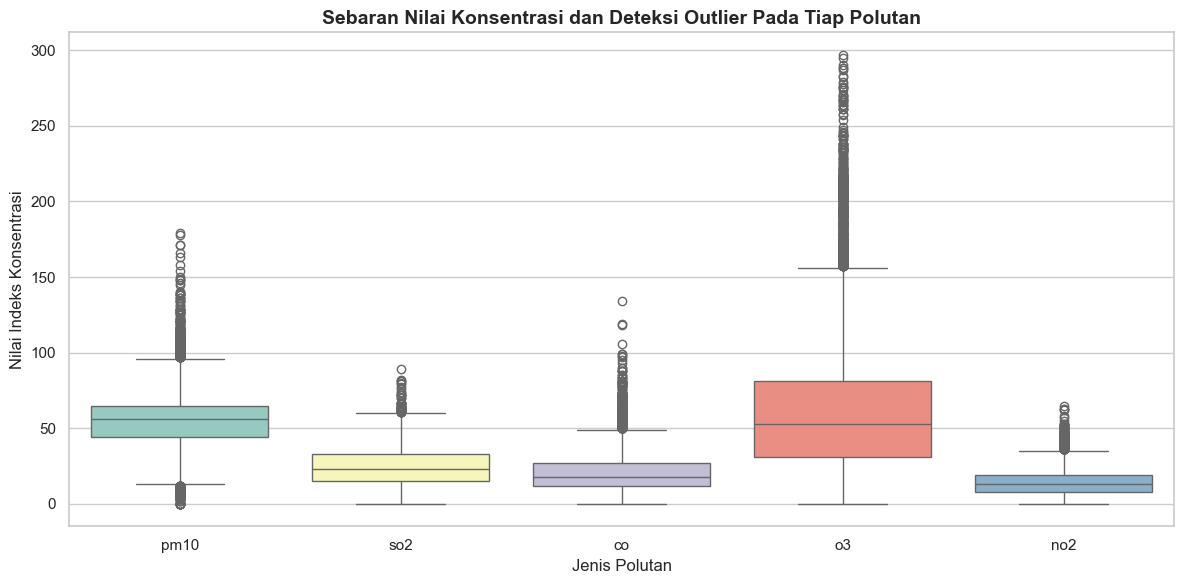

In [82]:
plt.figure(figsize=(12, 6))

df_melted = df_master.melt(id_vars=['kategori'], value_vars=['pm10', 'so2', 'co', 'o3', 'no2'], 
                           var_name='Jenis Polutan', value_name='Nilai Konsentrasi')

sns.boxplot(data=df_melted, x='Jenis Polutan', y='Nilai Konsentrasi', 
            hue='Jenis Polutan', legend=False,  # <-- Tambahkan ini untuk memperbaiki peringatan
            palette='Set3')

plt.title('Sebaran Nilai Konsentrasi dan Deteksi Outlier Pada Tiap Polutan', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Polutan', fontsize=12)
plt.ylabel('Nilai Indeks Konsentrasi', fontsize=12)
plt.tight_layout()
plt.show()

In [83]:
print("Feature engineering")

# 1. Menentukan kolom polutan utama dan target
kolom_polutan = ['pm10', 'so2', 'co', 'o3', 'no2']

# 2. Membuat dataframe khusus model hanya dengan polutan dan kategori (membuang tanggal, stasiun, max, critical)
df_model = df_master[kolom_polutan + ['kategori']].copy()

# 3. Encoding Kolom Target (Kategori)
# Karena tingkat polusi itu berurutan (Ordinal), kita ubah ke angka urut
map_kategori = {
    'BAIK': 0,
    'SEDANG': 1,
    'TIDAK SEHAT': 2,
    'SANGAT TIDAK SEHAT': 3
}
df_model['kategori'] = df_model['kategori'].map(map_kategori)

# 4. Memisahkan X (Fitur) dan y (Target) secara tegas
# Sekarang X dijamin HANYA berisi 5 zat polutan
X = df_model[kolom_polutan]
y = df_model['kategori']

print("Contoh data Fitur (X) siap model:")
print(X.head())
print(f"\nBentuk data akhir X: {X.shape} (Harus berakhiran 5 kolom)")
print(f"Bentuk data akhir y: {y.shape}")

Feature engineering
Contoh data Fitur (X) siap model:
   pm10   so2    co    o3   no2
0  35.0  13.0  12.0  31.0  18.0
1  23.0  14.0   9.0  32.0  11.0
2  20.0  13.0   8.0  33.0  13.0
3  30.0  21.0  11.0  28.0  18.0
4  38.0  50.0   8.0  19.0  27.0

Bentuk data akhir X: (14029, 5) (Harus berakhiran 5 kolom)
Bentuk data akhir y: (14029,)


In [84]:
# Cell Baru: Download Data Clean (df_master hasil pembersihan)
nama_file_clean = 'ispu_data_cleaned.csv'
df_master.to_csv(nama_file_clean, index=False)
print(f"Berhasil mengekspor! File tersimpan lokal dengan nama: '{nama_file_clean}'")


Berhasil mengekspor! File tersimpan lokal dengan nama: 'ispu_data_cleaned.csv'


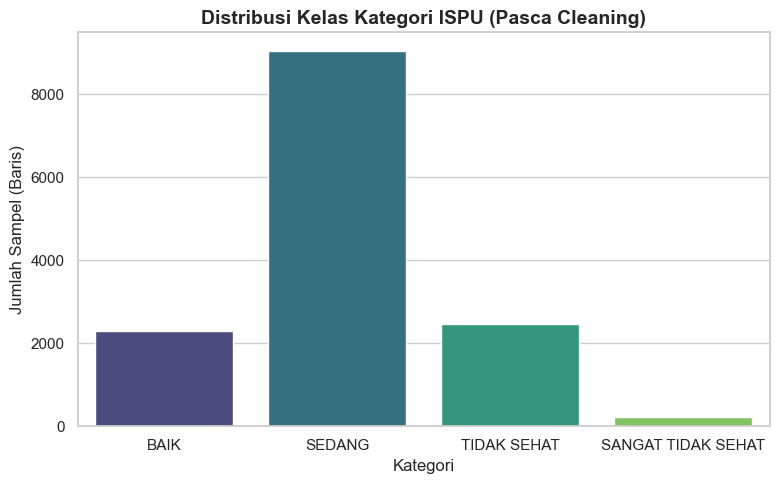

In [85]:
# Mengatur tema visualisasi agar terlihat rapi dan bersih
sns.set_theme(style="whitegrid")

# Cell Baru (Perbaikan): Visualisasi Distribusi Kategori ISPU
plt.figure(figsize=(8, 5))
sns.countplot(data=df_master, x='kategori', 
              order=['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT'], 
              hue='kategori', legend=False,  # <-- Tambahkan ini untuk memperbaiki peringatan
              palette='viridis')

plt.title('Distribusi Kelas Kategori ISPU (Pasca Cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Sampel (Baris)', fontsize=12)
plt.tight_layout()
plt.show()

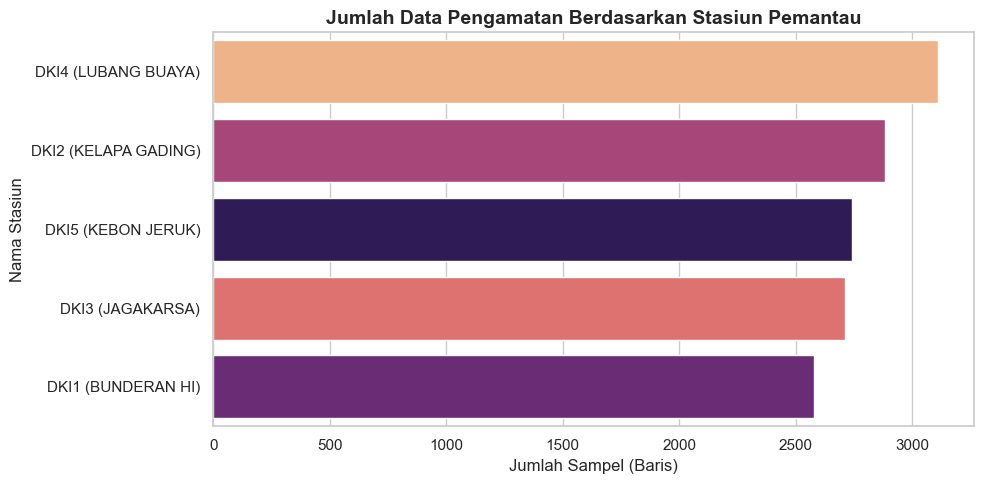

In [86]:
# Cell Baru (Perbaikan): Visualisasi Distribusi Data Per Stasiun Pemantau
plt.figure(figsize=(10, 5))
sns.countplot(data=df_master, y='stasiun', 
              order=df_master['stasiun'].value_counts().index, 
              hue='stasiun', legend=False,  # <-- Tambahkan ini untuk memperbaiki peringatan
              palette='magma')

plt.title('Jumlah Data Pengamatan Berdasarkan Stasiun Pemantau', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Sampel (Baris)', fontsize=12)
plt.ylabel('Nama Stasiun', fontsize=12)
plt.tight_layout()
plt.show()

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

print("Modeling dan evaluasi")

# 1. PERBAIKAN UTAMA: Ambil dari df_model agar target 'y' murni berbentuk ANGKA NUMERIK (0, 1, 2, 3)
kolom_polutan = ['pm10', 'so2', 'co', 'o3', 'no2']
X = df_model[kolom_polutan]
y = df_model['kategori']

# 2. Bagi data (Data Splitting)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== UKURAN DATA SETELAH SPLIT ===")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

# 3. Inisialisasi Model Random Forest (Fungsi balanced akan aktif maksimal pada target numerik)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 4. Latih Model
print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)
print("Training selesai.")

# 5. Uji Model dengan Data Testing
y_pred = rf_model.predict(X_test)

# 6. Lihat Nilai Rapornya
print("\nHasil evaluasi model")
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("Classification report:")
map_nama = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT', 3: 'SANGAT TIDAK SEHAT'}
kelas_unik = np.unique(np.concatenate([y_test, y_pred]))
target_names_fixed = [map_nama[k] for k in kelas_unik]
print(classification_report(y_test, y_pred, target_names=target_names_fixed))

Modeling dan evaluasi
=== UKURAN DATA SETELAH SPLIT ===
X_train: (11223, 5), y_train: (11223,)
X_test : (2806, 5), y_test : (2806,)

Training Random Forest...
Training selesai.

Hasil evaluasi model
Akurasi: 95.12%

Classification report:
                    precision    recall  f1-score   support

              BAIK       0.94      0.91      0.92       460
            SEDANG       0.95      0.97      0.96      1807
       TIDAK SEHAT       0.94      0.92      0.93       493
SANGAT TIDAK SEHAT       1.00      0.98      0.99        46

          accuracy                           0.95      2806
         macro avg       0.96      0.94      0.95      2806
      weighted avg       0.95      0.95      0.95      2806



In [88]:
file_X_train = 'X_train.csv'
file_y_train = 'y_train.csv'
file_X_test = 'X_test.csv'
file_y_test = 'y_test.csv'

X_train.to_csv(file_X_train, index=False)
y_train.to_csv(file_y_train, index=False)
X_test.to_csv(file_X_test, index=False)
y_test.to_csv(file_y_test, index=False)

print("Berhasil mengekspor seluruh data!")
print(f"-> Fitur Latihan  (X_train) tersimpan sebagai: '{file_X_train}'")
print(f"-> Target Latihan  (y_train) tersimpan sebagai: '{file_y_train}'")
print(f"-> Fitur Pengujian (X_test)  tersimpan sebagai: '{file_X_test}'")
print(f"-> Target Pengujian (y_test)  tersimpan sebagai: '{file_y_test}'")

Berhasil mengekspor seluruh data!
-> Fitur Latihan  (X_train) tersimpan sebagai: 'X_train.csv'
-> Target Latihan  (y_train) tersimpan sebagai: 'y_train.csv'
-> Fitur Pengujian (X_test)  tersimpan sebagai: 'X_test.csv'
-> Target Pengujian (y_test)  tersimpan sebagai: 'y_test.csv'


Gambar tingkat pengaruh fitur berhasil disimpan: 'feature_importance_main.png'


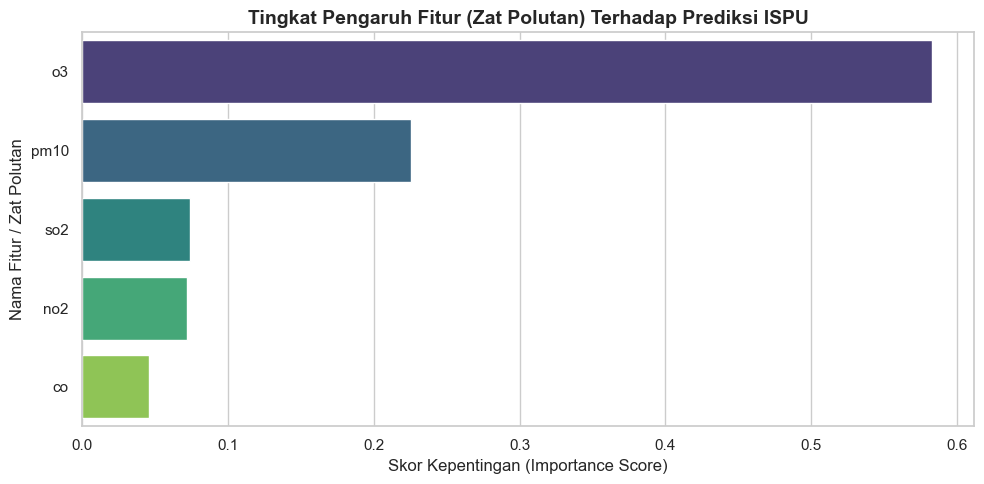

In [89]:
# Cell Baru: Visualisasi Fitur Paling Berpengaruh (Feature Importance)
import pandas as pd

# 1. Mengambil nilai tingkat kepentingan fitur dari model Anda
importances = rf_model.feature_importances_
fitur_nama = X_train.columns

# 2. Membuat DataFrame agar mudah diurutkan
fi_df = pd.DataFrame({
    'Fitur': fitur_nama,
    'Tingkat Kepentingan': importances
}).sort_values(by='Tingkat Kepentingan', ascending=False)

# 3. Plotting Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Tingkat Kepentingan', y='Fitur', 
            hue='Fitur', legend=False, palette='viridis')

plt.title('Tingkat Pengaruh Fitur (Zat Polutan) Terhadap Prediksi ISPU', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan (Importance Score)', fontsize=12)
plt.ylabel('Nama Fitur / Zat Polutan', fontsize=12)
plt.tight_layout()

# 4. Menyimpan gambar
nama_gambar_fi = 'feature_importance_main.png'
plt.savefig(nama_gambar_fi, dpi=300)
print(f"Gambar tingkat pengaruh fitur berhasil disimpan: '{nama_gambar_fi}'")

plt.show()

Visualisasi confusion matrix
Confusion matrix disimpan: 'confusion_matrix.png'

Cross validation (5-fold)
Proses cross validation...
Skor per fold: [94.69 95.19 95.12 94.73 94.47]
Rata-rata akurasi: 94.84%
Standar deviasi: 0.0027

Simpan model
Model disimpan: 'model_ispu_randomforest.pkl'
Model siap digunakan.


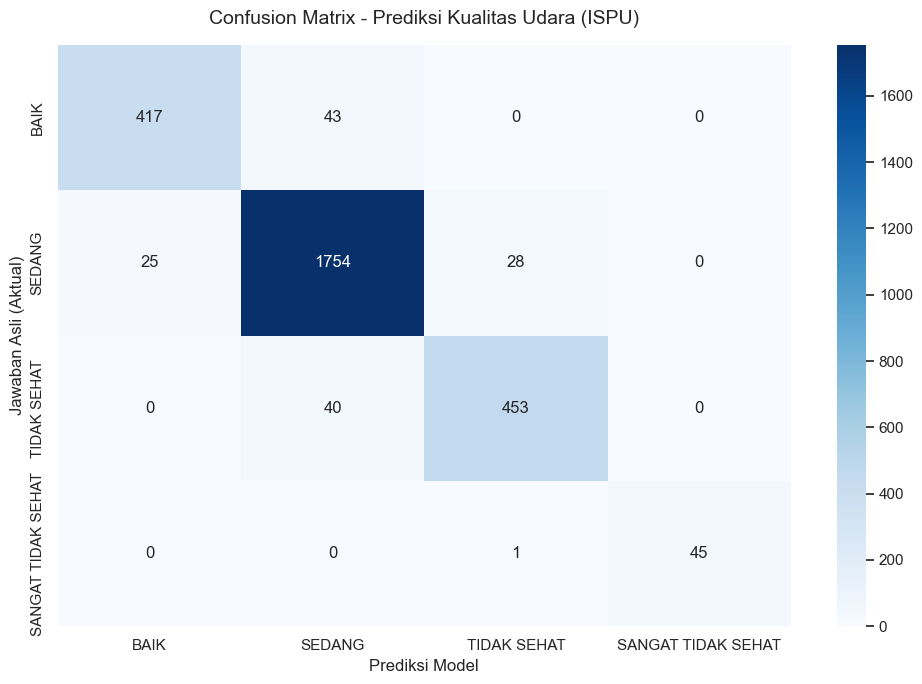

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import joblib

print("Visualisasi confusion matrix")

# 1. Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))

# Menggunakan Seaborn Heatmap untuk pewarnaan
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_fixed, yticklabels=target_names_fixed,
            annot_kws={"size": 12})

plt.title('Confusion Matrix - Prediksi Kualitas Udara (ISPU)', fontsize=14, pad=15)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Jawaban Asli (Aktual)', fontsize=12)
plt.tight_layout()

# Simpan gambarnya ke dalam folder yang sama dengan skrip ini
nama_file_gambar = 'confusion_matrix.png'
plt.savefig(nama_file_gambar, dpi=300)
print(f"Confusion matrix disimpan: '{nama_file_gambar}'")

print("\nCross validation (5-fold)")

# 2. Cross Validation
# Kita melipat data 5 kali (cv=5) untuk menguji kestabilan model di berbagai skenario pemotongan data
print("Proses cross validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print(f"Skor per fold: {np.round(scores * 100, 2)}")
print(f"Rata-rata akurasi: {scores.mean() * 100:.2f}%")
print(f"Standar deviasi: {scores.std():.4f}")

print("\nSimpan model")

# 3. Export Model ke file .pkl
nama_file_model = 'model_ispu_randomforest.pkl'
joblib.dump(rf_model, nama_file_model)
print(f"Model disimpan: '{nama_file_model}'")
print("Model siap digunakan.")

In [94]:
# Cell Baru: Simulasi Prediksi Data Udara Baru Secara Mandiri
print("=== SIMULASI PREDIKSI DATA BARU ===")

# Contoh beberapa input nilai polutan baru
data_baru = [
    [30.0,  12.0,  8.0,  25.0,  7.0],   
    [55.0,  25.0, 22.0,  58.0, 14.0],  
    [70.0,  28.0, 25.0, 111.0, 18.0],   
    [73.0,  25.0, 34.0, 200.0, 19.0],   
]

kolom_simulasi = ['pm10', 'so2', 'co', 'o3', 'no2']
df_simulasi = pd.DataFrame(data_baru, columns=kolom_simulasi)


prediksi_kategori = rf_model.predict(df_simulasi)
map_kategori_terbalik = {v: k for k, v in map_kategori.items()}
prediksi_kategori_nama = [map_kategori_terbalik[kode] for kode in prediksi_kategori]


print("Data simulasi setelah dicap:")
print(df_simulasi[kolom_simulasi])
print()

df_simulasi['Prediksi Kategori'] = prediksi_kategori_nama


print(df_simulasi)

=== SIMULASI PREDIKSI DATA BARU ===
Data simulasi setelah dicap:
   pm10   so2    co     o3   no2
0  30.0  12.0   8.0   25.0   7.0
1  55.0  25.0  22.0   58.0  14.0
2  70.0  28.0  25.0  111.0  18.0
3  73.0  25.0  34.0  200.0  19.0

   pm10   so2    co     o3   no2   Prediksi Kategori
0  30.0  12.0   8.0   25.0   7.0                BAIK
1  55.0  25.0  22.0   58.0  14.0              SEDANG
2  70.0  28.0  25.0  111.0  18.0         TIDAK SEHAT
3  73.0  25.0  34.0  200.0  19.0  SANGAT TIDAK SEHAT


Grafik visualisasi probabilitas berhasil disimpan dengan nama: 'visualisasi_prediksi_data_baru.png'


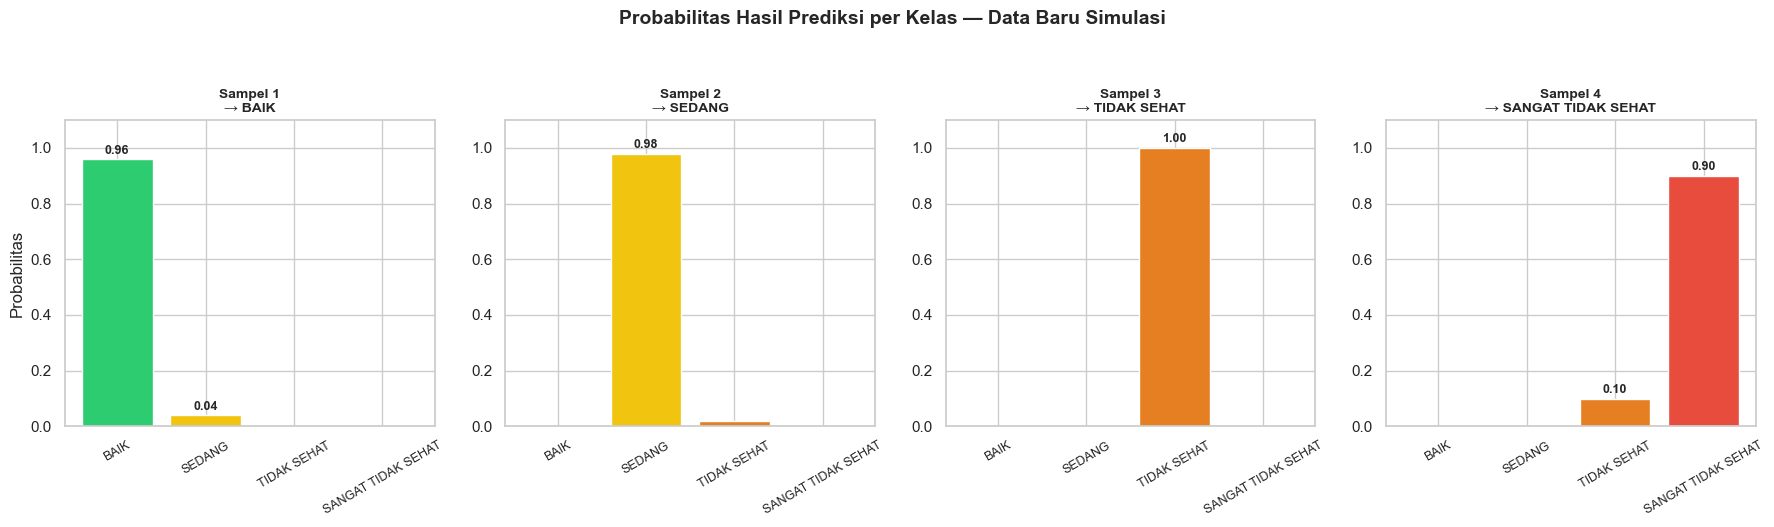

In [95]:
# Cell Baru: Visualisasi Probabilitas Prediksi per Sampel Data Baru
import matplotlib.pyplot as plt

# 1. Menghitung probabilitas prediksi untuk setiap sampel data baru
# Fungsi ini menghasilkan array berisi persentase keyakinan pohon keputusan model
y_proba_new = rf_model.predict_proba(df_simulasi[kolom_simulasi])

# 2. Mengambil nama-nama kategori yang ada berdasarkan kelas yang dipelajari model
present_class_names = [map_kategori_terbalik[c] for c in rf_model.classes_]

# 3. Menyiapkan palet warna representatif untuk setiap kategori (Baik, Sedang, Tidak Sehat, Sangat Tidak Sehat)
colors_prob = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

# 4. Membuat bidang gambar (subplots) berjajar ke samping sebanyak jumlah baris data baru
fig, axes = plt.subplots(1, len(df_simulasi), figsize=(18, 5))

# Loop untuk menggambar bar chart di setiap subplots sampel data
for i, (proba, pred) in enumerate(zip(y_proba_new, prediksi_kategori)):
    # Mengambil warna yang sesuai dengan indeks kelas yang ada pada model
    colors_mapped = [colors_prob[c] for c in rf_model.classes_]
    
    # Membuat diagram batang
    axes[i].bar(present_class_names, proba, color=colors_mapped, edgecolor='white')
    
    # Memberikan judul di atas tiap grafik batang sampel
    axes[i].set_title(f'Sampel {i+1}\n→ {map_kategori_terbalik[pred]}', fontsize=10, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Probabilitas' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=30, labelsize=9)
    
    # Menampilkan teks angka persentase probabilitas di atas batang (jika di atas 3%)
    for j, p in enumerate(proba):
        if p > 0.03:
            axes[i].text(j, p + 0.02, f'{p:.2f}', ha='center', fontsize=9, fontweight='bold')

# Memberikan judul utama di bagian paling atas diagram luar
plt.suptitle('Probabilitas Hasil Prediksi per Kelas — Data Baru Simulasi', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()

# Menyimpan gambar secara otomatis ke direktori lokal Windows Anaconda Anda
nama_plot_prediksi = 'visualisasi_prediksi_data_baru.png'
plt.savefig(nama_plot_prediksi, dpi=150, bbox_inches='tight')
print(f"Grafik visualisasi probabilitas berhasil disimpan dengan nama: '{nama_plot_prediksi}'")

plt.show()